In [1]:
import rasterio
import os
import numpy as np
import glob
from PIL import Image

In [2]:
image_1 = "/data/integracar/amostras_car/ES-3204906-FEC6452DE4354398BB52137330D93B31.tif"

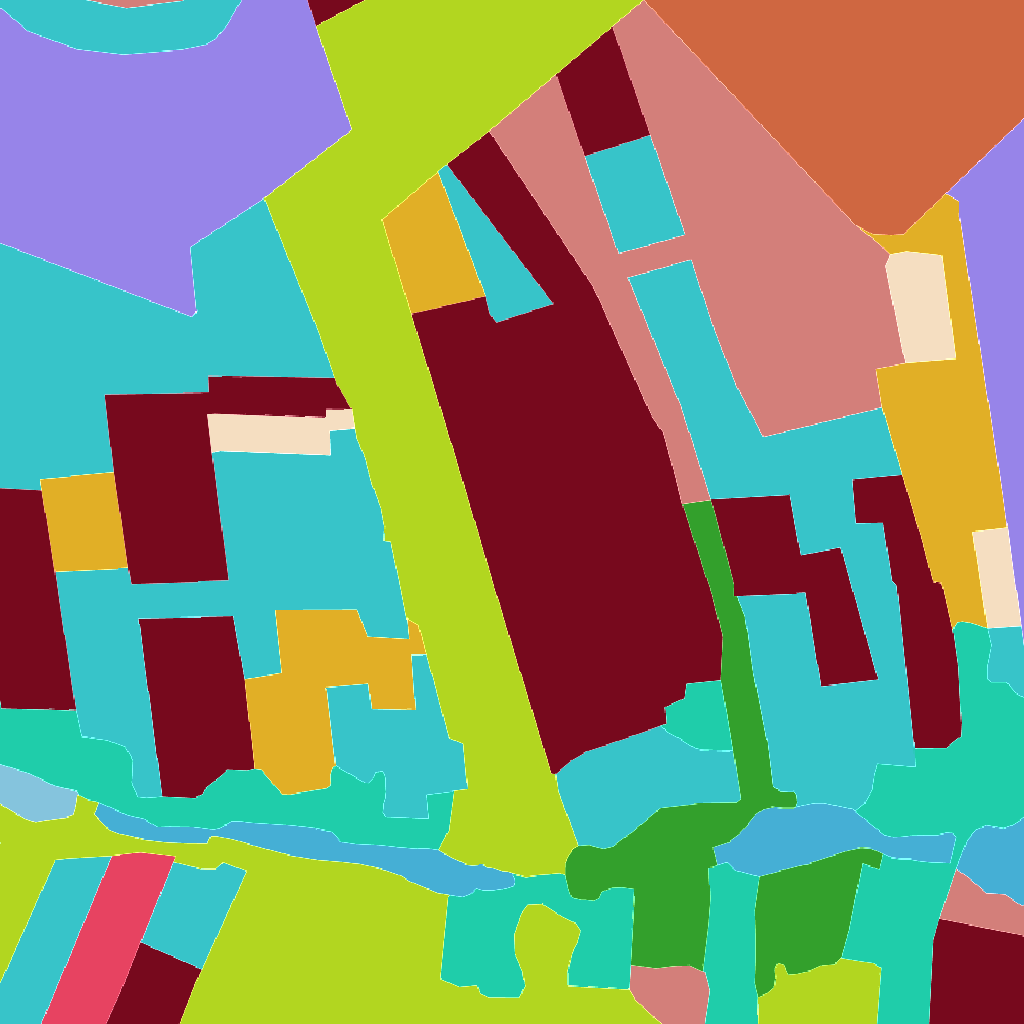

In [3]:
Image.open(image_1).convert('RGB')

In [4]:
rasterio.open(image_1).read()

array([[[ 55,  55,  55, ..., 207, 207, 207],
        [ 55,  55,  55, ..., 207, 207, 207],
        [ 55,  55,  55, ..., 207, 207, 207],
        ...,
        [ 55,  55,  55, ..., 119, 119, 119],
        [ 55,  55,  55, ..., 119, 119, 119],
        [ 55,  55,  55, ..., 119, 119, 119]],

       [[196, 196, 196, ..., 103, 103, 103],
        [196, 196, 196, ..., 103, 103, 103],
        [196, 196, 196, ..., 103, 103, 103],
        ...,
        [196, 196, 196, ...,   9,   9,   9],
        [196, 196, 196, ...,   9,   9,   9],
        [196, 196, 196, ...,   9,   9,   9]],

       [[201, 201, 201, ...,  65,  65,  65],
        [201, 201, 201, ...,  65,  65,  65],
        [201, 201, 201, ...,  65,  65,  65],
        ...,
        [201, 201, 201, ...,  29,  29,  29],
        [201, 201, 201, ...,  29,  29,  29],
        [201, 201, 201, ...,  29,  29,  29]],

       [[255, 255, 255, ..., 255, 255, 255],
        [255, 255, 255, ..., 255, 255, 255],
        [255, 255, 255, ..., 255, 255, 255],
        ..

In [61]:
from zipfile import compressor_names

from tqdm import tqdm
import glob
import rasterio
import numpy as np
import json
import os

# from count_classes import legend_rgb

output_tif = "teste-imagem"
os.makedirs(output_tif, exist_ok=True)

def convert_pixels(convert_type):
    if convert_type == "Full":
        legend_rgb = {
            (150, 150, 150): 0, #Afloramento Rochoso
            (251, 154, 153): 1, #Área Edificada
            (69, 175, 213): 2, #Brejo
            (150, 109, 207): 3,#Campo Rupestre/Altitude
            (128, 214, 16): 4, #Cultivo Agrícola - Abacaxi
            (247, 223, 8): 5, #Cultivo Agrícola - Banana
            (119, 9, 29): 6, #Cultivo Agrícola - Café
            (209, 163, 117): 7, #Cultivo Agrícola - Cana-De-Açúcar
            (231, 67, 97): 8, #Cultivo Agrícola - Coco-Da-Baía
            (245, 141, 23): 9, #Cultivo Agrícola - Mamão
            (55, 196, 201): 10, #Cultivo Agrícola - Outros Cultivos Permanentes
            (225, 175, 38): 11, #Cultivo Agrícola - Outros Cultivos Temporários
            (81, 77, 77): 12, #Extração Mineração
            (211, 127, 122): 13, #Macega
            (156, 68, 203): 14, #Mangue
            (133, 196, 221): 15, #Massa D'Água
            (13, 103, 19): 16, #Mata Nativa
            (51, 160, 44): 17, #Mata Nativa em Estágio Inicial de Regeneração
            (31, 205, 170): 18, #Outros
            (178, 214, 32): 19, #Pastagem
            (207, 103, 65): 20, #Reflorestamento - Eucalipto
            (243, 184, 129): 21, #Reflorestamento - Pinus
            (151, 132, 233): 22, #Reflorestamento - Seringueira
            (63, 231, 161): 23, #Restinga
            (245, 222, 193): 24 #Solo Exposto
        }

        legend_names = {
            0: "Afloramento Rochoso",
            1: "Área Edificada",
            2: "Brejo",
            3: "Campo Rupestre/Altitude",
            4: "Cultivo Agrícola - Abacaxi",
            5: "Cultivo Agrícola - Banana",
            6: "Cultivo Agrícola - Café",
            7: "Cultivo Agrícola - Cana-De-Açúcar",
            8: "Cultivo Agrícola - Coco-Da-Baía",
            9: "Cultivo Agrícola - Mamão",
            10: "Cultivo Agrícola - Outros Cultivos Permanentes",
            11: "Cultivo Agrícola - Outros Cultivos Temporários",
            12: "Extração Mineração",
            13: "Macega",
            14: "Mangue",
            15: "Massa D'Água",
            16: "Mata Nativa",
            17: "Mata Nativa em Estágio Inicial de Regeneração",
            18: "Outros",
            19: "Pastagem",
            20: "Reflorestamento - Eucalipto",
            21: "Reflorestamento - Pinus",
            22: "Reflorestamento - Seringueira",
            23: "Restinga",
            24: "Solo Exposto"
        }

        return legend_names, legend_rgb

    elif convert_type=="binary_forest":
        legend_rgb = {
            (150, 150, 150): 0, #Afloramento Rochoso
            (251, 154, 153): 0, #Área Edificada
            (69, 175, 213): 0, #Brejo
            (150, 109, 207): 0,#Campo Rupestre/Altitude
            (128, 214, 16): 1, #Cultivo Agrícola - Abacaxi
            (247, 223, 8): 1, #Cultivo Agrícola - Banana
            (119, 9, 29): 1, #Cultivo Agrícola - Café
            (209, 163, 117): 1, #Cultivo Agrícola - Cana-De-Açúcar
            (231, 67, 97): 1, #Cultivo Agrícola - Coco-Da-Baía
            (245, 141, 23): 1, #Cultivo Agrícola - Mamão
            (55, 196, 201): 1, #Cultivo Agrícola - Outros Cultivos Permanentes
            (225, 175, 38): 1, #Cultivo Agrícola - Outros Cultivos Temporários
            (81, 77, 77): 0, #Extração Mineração
            (211, 127, 122): 1, #Macega
            (156, 68, 203): 1, #Mangue
            (133, 196, 221): 0, #Massa D'Água
            (13, 103, 19): 1, #Mata Nativa
            (51, 160, 44): 1, #Mata Nativa em Estágio Inicial de Regeneração
            (31, 205, 170): 0, #Outros
            (178, 214, 32): 1, #Pastagem
            (207, 103, 65): 1, #Reflorestamento - Eucalipto
            (243, 184, 129): 1, #Reflorestamento - Pinus
            (151, 132, 233): 1, #Reflorestamento - Seringueira
            (63, 231, 161): 1, #Restinga
            (245, 222, 193): 0, #Solo Exposto
            # (255, 255, 255): 2 # linhas nulas
        }

        legend_names = {
            0: "sem_vegetacao",
            1: "com_vegetacao",
            2: "nulos"
        }

        return legend_names, legend_rgb

    else:
        raise TypeError("Tipo de conversão não definido!!!")


legend_names, legend_rgb = convert_pixels(convert_type="binary_forest")

mask_path = image_1

with rasterio.open(mask_path) as src:
    img = src.read()  # (C, H, W)
    profile = src.profile

# Converter para (H, W, 3)
img_rgb = np.transpose(img[:3], (1, 2, 0))

# Criar raster vazio
# class_map = np.zeros((img_rgb.shape[0], img_rgb.shape[1]), dtype=np.uint8)

# Inicializar class_map com valor padrão 2 (ao invés de 0)
class_map = np.full((img_rgb.shape[0], img_rgb.shape[1]), 2, dtype=np.uint8)

for rgb, class_id in legend_rgb.items():
    mask = np.all(img_rgb == rgb, axis=-1)
    class_map[mask] = class_id
    
# Atualizar perfil para 1 banda
profile.update(dtype=rasterio.uint8, count=1)

base_name = os.path.splitext(os.path.basename(mask_path))[0]
output_path = os.path.join(output_tif, f'{base_name}.tif')

# Salvar raster classificado
with rasterio.open(output_path, "w", **profile) as dst:
    dst.write(class_map, 1)

    #print("✅ Raster classificado salvo em:", output_path)

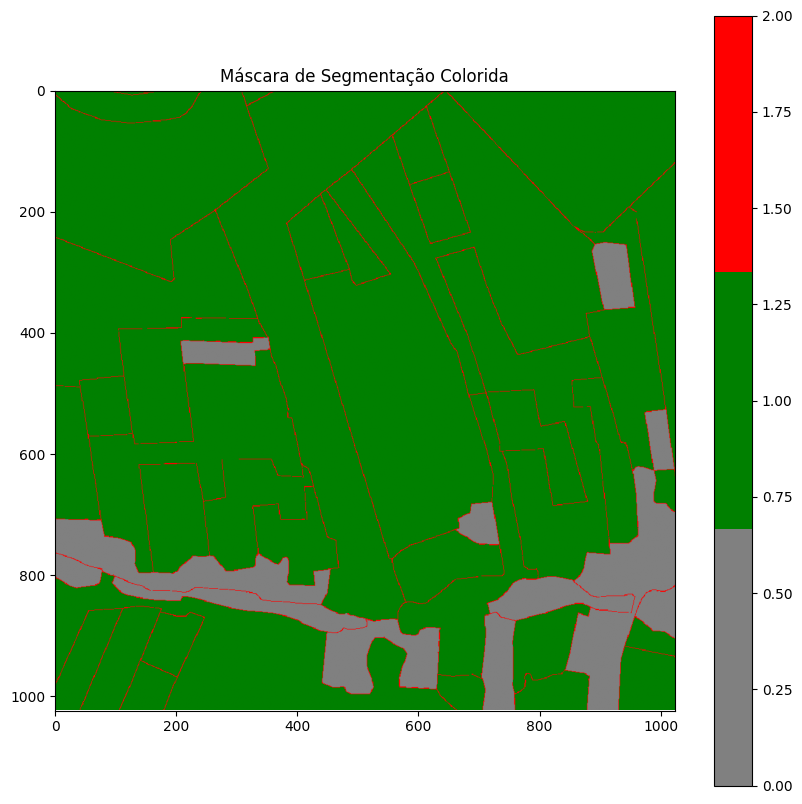

In [62]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import numpy as np
from PIL import Image

image_path = "teste-imagem/ES-3204906-FEC6452DE4354398BB52137330D93B31.tif"

# 1. Carregar a imagem (importar para array numpy)
# Usamos o PIL para garantir suporte a TIF e converter para array
mask_gray = np.array(Image.open(image_path))
cmap = ListedColormap(['gray', 'green', 'red'])
# 2. Plotar com mapa de cores discreto
plt.figure(figsize=(10, 10))
plt.imshow(mask_gray, cmap=cmap)
plt.colorbar() # Mostra a barra de cores para identificar os valores das classes
plt.title("Máscara de Segmentação Colorida")
plt.show()


In [8]:
# Inicializar class_map com valor padrão 2 (ao invés de 0)
class_map = np.full((img_rgb.shape[0], img_rgb.shape[1]), 2, dtype=np.uint8)

# Converter cores → IDs (isso vai sobrescrever os pixels que encontrar)
for rgb, class_id in legend_rgb.items():
    mask = np.all(img_rgb == rgb, axis=-1)
    class_map[mask] = class_id


Classes presentes: {0: 135691, 1: 912885}


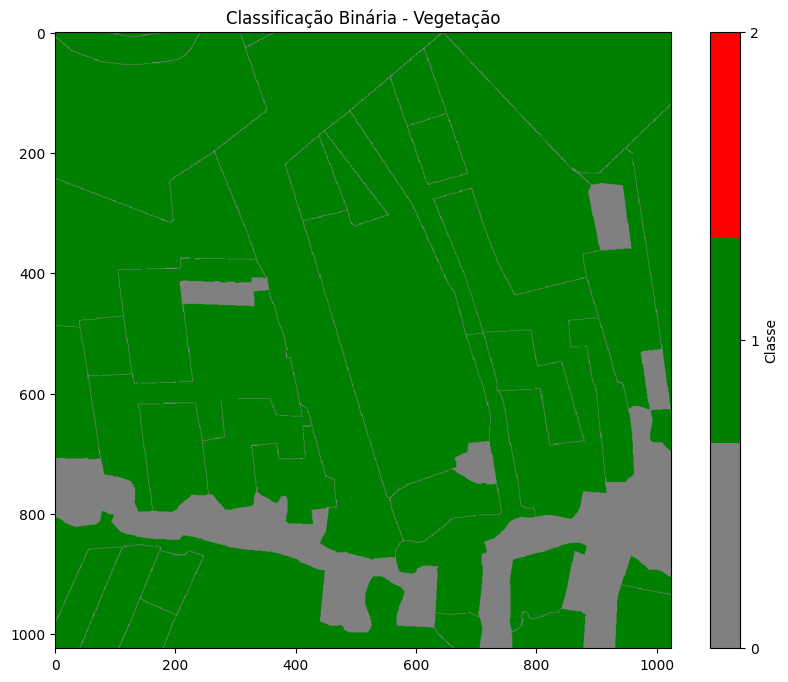

In [9]:
import rasterio
from rasterio.plot import show
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# Abrir o raster salvo
with rasterio.open(output_path) as src:
    data = src.read(1)
    
    # Contar valores únicos
    unique, counts = np.unique(data, return_counts=True)
    print("Classes presentes:", dict(zip(unique, counts)))
    
    # Visualizar com colormap personalizado
    cmap = ListedColormap(['gray', 'green', 'red'])
    plt.figure(figsize=(10, 8))
    plt.imshow(data, cmap=cmap, vmin=0, vmax=2)
    plt.colorbar(label='Classe', ticks=[0, 1, 2])
    plt.title('Classificação Binária - Vegetação')
    plt.show()
